In [112]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import log_loss, confusion_matrix 
from sklearn.metrics import brier_score_loss
from sklearn.impute import KNNImputer, SimpleImputer
from imblearn.under_sampling import NearMiss 
from sklearn.metrics import classification_report
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve
import statsmodels.api as sm
import sys
import shap
import math
import xgboost as xgb
sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)
from utils import read_data, convert_multiple_cases, encode_cyclical, optimal_threashold_fbeta_scalar, plot_imbalance, plot_imbalance_vertical, dataframe_describe
from utils import plot_roc_curve, plot_pr_curve, plot_probability_curve, binary_entropy, yearCV_split
import warnings
warnings.filterwarnings("ignore")

NUTS0 = 'GR'

file1 = r'E:\Drive\NOA\MBD-Prediction\GRID Level\data\GR_WNV_Dataset_GRID_OP_2010_2021.csv'

dataset = read_data(file1)

dataset.head()

dataset.reset_index(drop = True, inplace = True)

print(dataset.shape)

(664560, 92)


In [113]:
dataset.head()

,cell_code,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type,cases
0,AAE407,EL43,EL434,αποκορωνου,2010,1,24.117404,35.410691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.105484,12.522258,13.950714,19.048065,22.682667,9.001613,9.339677,7.253571,9.301613,11.206,10.553548,10.930968,10.602143,14.174839,16.944333,3.110,20.630,10.158791,8.697677,20.032296,307.352892,449.754390,19.250000,18.666667,47.863248,773.275207,42.0,3.0,39.0,10.666667,29.000000,29.000000,10.500000,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,22,20,20,9,9,4,1,1,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.000000,52.950027,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
1,AAE468,EL43,EL433,μυλοποταμου,2010,1,24.789225,35.408170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.274,18.134,8.900615,5.977331,8.328200,275.917567,363.227389,16.833333,20.500000,50.000000,796.107957,41.0,0.0,41.0,8.500000,27.333333,27.333333,7.833333,1746.0,328.0,0.0,81.286010,818.0,1.0,1.0,655.0,31,30,50,11,10,1,6,6,0.000000,4784.892552,13,63.847297,51.029019,188.997189,1.128647,6.233711,7596.0,27753.0,6190.0,41539.0,7371.0,28024.0,7574.0,42969.0,1457.56,2031.0,2221.0,3,3,1,0
2,AAF412,EL43,EL434,αποκορωνου,2010,1,24.172455,35.401609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.062258,13.808065,15.227857,19.090645,22.681333,9.595161,9.121613,7.030714,8.535161,10.694,11.828710,11.464839,11.129286,13.812903,16.687667,5.970,20.070,10.158791,8.697677,20.032296,307.352892,449.754390,19.458333,20.583333,46.780303,795.000953,44.0,0.0,44.0,10.500000,29.500000,29.500000,10.166667,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,31,30,30,10,10,1,6,6,5449.996872,871.966870,11,251.863885,182.026884,183.272934,0.000000,3.239146,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
3,AAF418,EL43,EL434,αποκορωνου,2010,1,24.238531,35.401496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.268065,13.366774,14.356429,18.776452,21.927333,8.675161,8.922258,7.170000,8.628065,10.402,11.471613,11.144516,10.763214,13.702258,16.164667,5.470,19.870,9.615967,6.088871,14.048537,297.686708,442.198871,18.916667,18.833333,45.934959,773.373170,42.0,1.0,41.0,10.500000,28.666667,28.666667,10.166667,2022.0,366.0,2.0,79.439558,985.0,14.0,14.0,854.0,22,20,20,9,9,4,2,2,2072.028070,3644.010740,6,148.262387,301.797520,184.889754,0.000000,9.160420,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
4,AAF461,EL43,EL433,μυλοποταμου,2010,1,24.712056,35.399633,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.909355,13.180968,15.556429,20.501613,24.858000,9.899032,8.513226,7.876429,9.155806,10.950,13.404194,10.847097,11.716429,14.828710,17.904000,6.510,21.790,8.895365,8.553344,15.224943,275.746825,414.026678,19.416667,20.833333,49.603175,783.591189,42.0,0.0,42.0,11.000000,29.166667,29.166667,9.833333,1825.0,345.0,0.0,81.455549,855.0,4.0,4.0,707.0,31,36,30,12,12,1,6,7,2719.492211,298.312749,10,176.489002,56.734191,180.2360

In [114]:
len(dataset.cell_code.unique())

4260

In [115]:
dataset = encode_cyclical(dataset, 'month', 12)

In [116]:
dataset.cases.sum()

1364

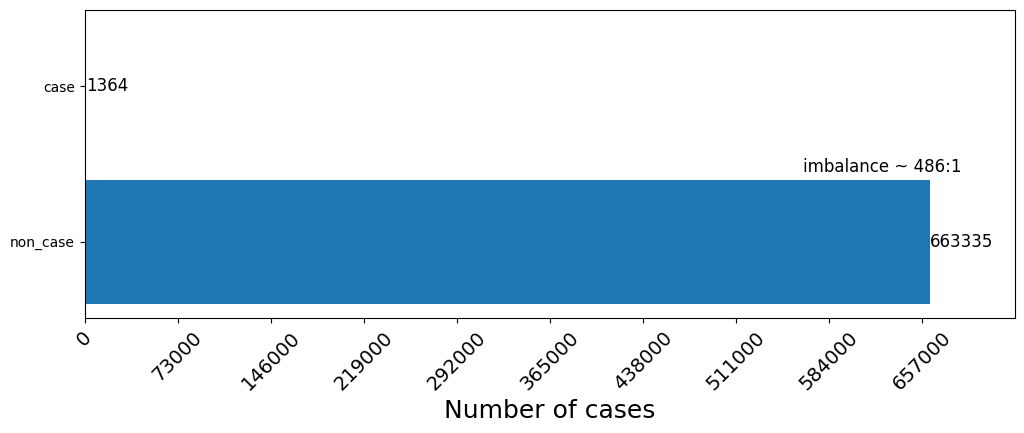

In [117]:
plot_imbalance(dataset, target_column='cases')

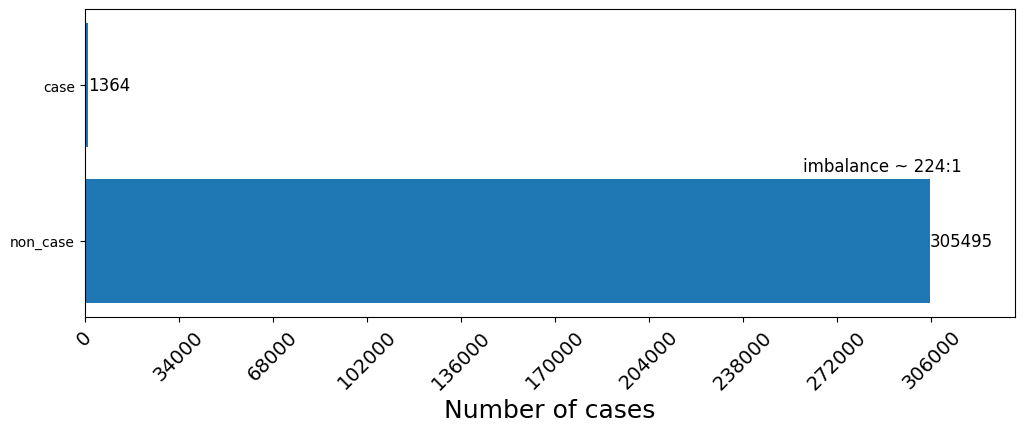

In [118]:
dataset = dataset.query('month >= 5 & month <= 10 & year <= 2021')
# dataset = dataset.query('month >= 5')
dataset.reset_index(drop=True, inplace=True)

plot_imbalance(dataset, target_column='cases')

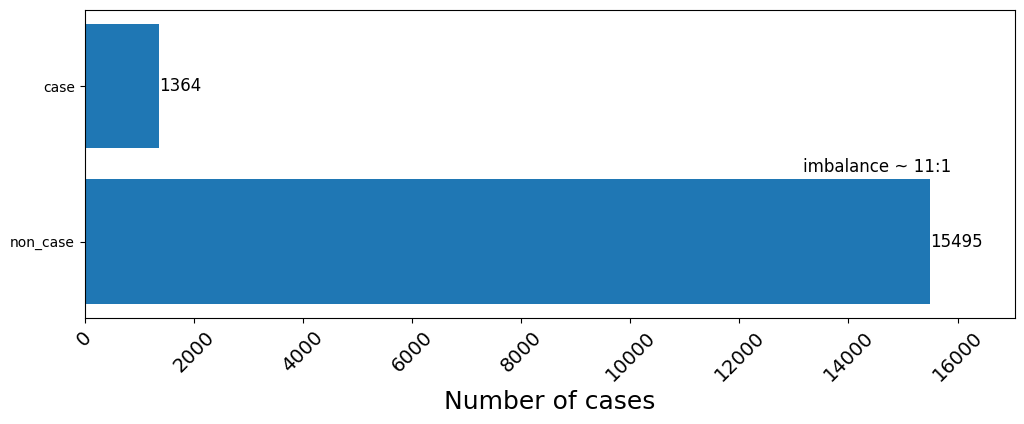

In [119]:
rows_to_remove = dataset.query('cases == 0').sample(n=290000, random_state=0).index

dataset.drop(rows_to_remove, inplace=True)
dataset.reset_index(drop=True, inplace=True)

plot_imbalance(dataset, target_column='cases')

In [120]:
dataset.shape

(16720, 94)

In [121]:
dataset.cases.sum()

1364

In [122]:
dsc = dataframe_describe(dataset, target_column = 'cases')
dsc.head(15)

,year,non-case,case,total,0/1 ratio
0,2010,1299,262,1561,4.96%
1,2011,1268,100,1368,12.68%
2,2012,1281,157,1438,8.16%
3,2013,1307,85,1392,15.38%
4,2014,1242,15,1257,82.80%
5,2015,1339,0,1339,inf%
6,2016,1300,0,1300,inf%
7,2017,1233,42,1275,29.36%
8,2018,1243,296,1539,4.20%
9,2019,1325,218,1543,6.08%


In [123]:
X = dataset.select_dtypes(exclude=['object']).drop(columns=['cases'])
y = dataset['cases']

In [124]:
features_to_remove = ['year', 'month']

feature_names = X.select_dtypes(exclude=['object']).drop(columns = features_to_remove).columns
print(feature_names.to_list())

print(f"Total Features Used: {len(feature_names)}")

['x', 'y', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_night_mean', 'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'monthly_lst_min', 'monthly_lst_max', 'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_month', 'acc_rainfall_jan', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'males_lt15', 'males_15

In [125]:
print(feature_names)

Index(['x', 'y', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean',
       'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_night_mean',
       'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean',
       'lst_apr_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean',
       'lst_mar_mean', 'lst_apr_mean', 'monthly_lst_min', 'monthly_lst_max',
       'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_month', 'acc_rainfall_jan', 'bio1', 'bio2', 'bio3',
       'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11',
       'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19',
       'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1', 'lc_type2', 'lc_type3',
       'lc_type4', 'lc_type5', 'distance_to_coast', 'distance_to_river',
       'slope_mean_1km', 'aspect_mean_200m', 'el

In [126]:
weights = pd.Series(y.clip(lower=1).values, name = 'weights')

weights_new = np.ceil(weights / 1).astype(int)

In [127]:
fold_counter = 0
y_train_list = []
y_test_list = []
y_train_prob_list = []
y_test_prob_list = []

years = [2021]

for test_year in years:
    train_idx = dataset.index[dataset["year"] < test_year].tolist()
    test_idx = dataset.index[dataset["year"] == test_year].tolist()

    print(f"Train: 2010-{test_year-1} | Test: {test_year}")
    print(f"Train size: {len(train_idx)} | Test size: {len(test_idx)}")

    data_train = dataset.iloc[train_idx].copy()
    data_test = dataset.iloc[test_idx].copy()
    weights_train = weights_new.iloc[train_idx].copy()

    data_train['cases'] = data_train['cases'].apply(lambda x: 1 if x > 0 else 0)
    data_test['cases'] = data_test['cases'].apply(lambda x: 1 if x > 0 else 0)

    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)

    sum_negatives = data_train['cases'].value_counts().get(0)
    sum_positives = data_train['cases'].value_counts().get(1)

    params = {
        "objective": "binary:logistic",
        "device": "gpu",
        "eval_metric": "logloss",
         "learning_rate": 0.05,
        "n_estimators": 300,
        "max_depth": 2,
        "min_child_weight": 5,
        "gamma": 0,
        "subsample": 0.7,
        "colsample_bytree": 0.7,
        "reg_alpha": 0,
        "reg_lambda": 3.0,
        "scale_pos_weight": sum_negatives / sum_positives,
        "random_state": 42,
    }


    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])

    y_train = data_train['cases']
    y_test = data_test['cases']

    print(f"Training set 0/1 Ratio: {(sum_negatives / sum_positives):.2f}")
    print(f"Test set 0/1 Ratio: {(sum_negatives / sum_positives):.2f}")
    print(f"Weight: {(sum_negatives/sum_positives):.2f}")
        
    imputer = SimpleImputer()
    imputer.fit(X_train)
    X_train_imputed = imputer.transform(X_train)
    X_test_imputed = imputer.transform(X_test)

    model = xgb.XGBClassifier(**params)  

    trained_model = model.fit(X_train_imputed, y_train, sample_weight = weights_train)

    # calibrated_model = CalibratedClassifierCV(model,method="isotonic",cv=3)

    # trained_model = calibrated_model.fit(X_train_imputed, y_train, sample_weight = weights_train)

    y_train_prob = trained_model.predict_proba(X_train_imputed)
    y_test_prob = trained_model.predict_proba(X_test_imputed)

    y_train_list.append(y_train)
    y_test_list.append(y_test)
    y_train_prob_list.append(y_train_prob)
    y_test_prob_list.append(y_test_prob)
    fold_counter += 1

Train: 2010-2020 | Test: 2021
Train size: 15394 | Test size: 1326
Training set 0/1 Ratio: 12.12
Test set 0/1 Ratio: 12.12
Weight: 12.12


In [128]:
y_train_true = np.concatenate(y_train_list, axis=0)
y_test_true = np.concatenate(y_test_list, axis=0)

y_train_proba = np.concatenate(y_train_prob_list, axis = 0)
y_test_proba = np.concatenate(y_test_prob_list, axis = 0)

In [129]:
df_test = pd.DataFrame({'score': y_test_proba[:, 1], 'target': y_test_true}, index = test_idx)

In [131]:
df_test = df_test.merge(dataset.iloc[test_idx][['cell_code', 'nuts3_id', 'lau1', 'x', 'y', 'year', 'month', 'cases']], left_index=True, right_index=True)
df_test.rename(columns = {'score': 'risk_score'}, inplace = True)
df_test = df_test[['cell_code', 'nuts3_id', 'lau1', 'x', 'y', 'year', 'month', 'risk_score', 'target', 'cases']].copy()

In [132]:
df_test

,cell_code,nuts3_id,lau1,x,y,year,month,risk_score,target,cases
15394,AAE407,EL434,αποκορωνου,24.117404,35.410691,2021,5,0.001453,0,0
15395,AB410,EL514,κατω νευροκοπιου,24.163734,41.529853,2021,5,0.003098,0,0
15396,BF299,EL523,κιλκις,22.838134,41.253880,2021,5,0.009587,0,0
15397,BF341,EL526,σιντικης,23.339406,41.257848,2021,5,0.025128,0,0
15398,BI316,EL526,σιντικης,23.041412,41.228730,2021,5,0.026337,0,0
...,...,...,...,...,...,...,...,...,...,...
16715,QR278,EL651,αργους μυκηνων,22.658869,37.629859,2021,10,0.011251,0,0
16716,QR491,EL422,τηνου,25.072809,37.632604,2021,10,0.025875,0,0
16717,RE202,EL633,ανδριτσαινας κρεστενων,21.801488,37.499843,2021,10,0.014983,0,0
16718,RH227,EL651,μεγαλοπολης,22.084840,37.477741,2021,10,0.017056,0,0


In [133]:
train_loss = log_loss(y_train_true, y_train_proba[:, 1])
print(f"Train Logloss: {train_loss:.4f}")

test_loss = log_loss(y_test_true, y_test_proba[:, 1])
print(f"Test Loss: {test_loss:.4f}")

Train Logloss: 0.3061
Test Loss: 0.3072


In [134]:
classification_thresholds = optimal_threashold_fbeta_scalar(y_test_proba[:,1], y_test_true, beta = 2, round_factor = 2)
print(classification_thresholds)

thr = classification_thresholds

0.75


In [135]:
y_train_pred = np.where(y_train_proba[:,1] > thr, 1, 0)
y_test_pred = np.where(y_test_proba[:,1] > thr, 1, 0)

print(classification_report(y_test_true, y_test_pred, output_dict=False))

              precision    recall  f1-score   support

           0       0.99      0.96      0.97      1274
           1       0.38      0.65      0.48        52

    accuracy                           0.94      1326
   macro avg       0.68      0.81      0.73      1326
weighted avg       0.96      0.94      0.95      1326



In [136]:
brier = brier_score_loss(y_test_true, y_test_proba[:,1])

print("Brier score:", brier)

Brier score: 0.10207478405078309


In [137]:
'''
MCM = [[TN, FP],
       [FN, TP]]
'''


cm = confusion_matrix(y_test_true, y_test_pred)

print(cm)

[[1219   55]
 [  18   34]]


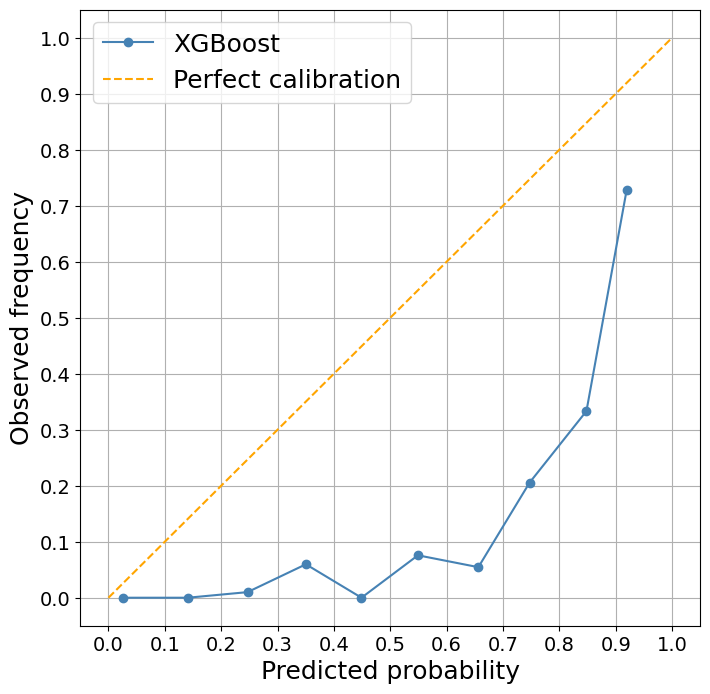

In [138]:
tick_size = 14
label_size = 18
legend_size = 18
text_size = 18

prob_true, prob_pred = calibration_curve(
    y_test_true,
    y_test_proba[:,1],
    n_bins=10,
    strategy="uniform"
)

plt.subplots(1, figsize=(8,8))

plt.plot(prob_pred, prob_true, marker="o", color = 'steelblue', label="XGBoost")
plt.plot([0,1], [0,1], linestyle="--", color = 'orange', label="Perfect calibration")

plt.xlabel("Predicted probability", size=label_size)
plt.ylabel("Observed frequency", size=label_size)
plt.yticks(np.arange(0, 1.1, step = 0.1), size=tick_size)
plt.xticks(np.arange(0, 1.1, step = 0.1), size=tick_size)
plt.legend(prop={'size': legend_size})
plt.grid(True)
plt.show()

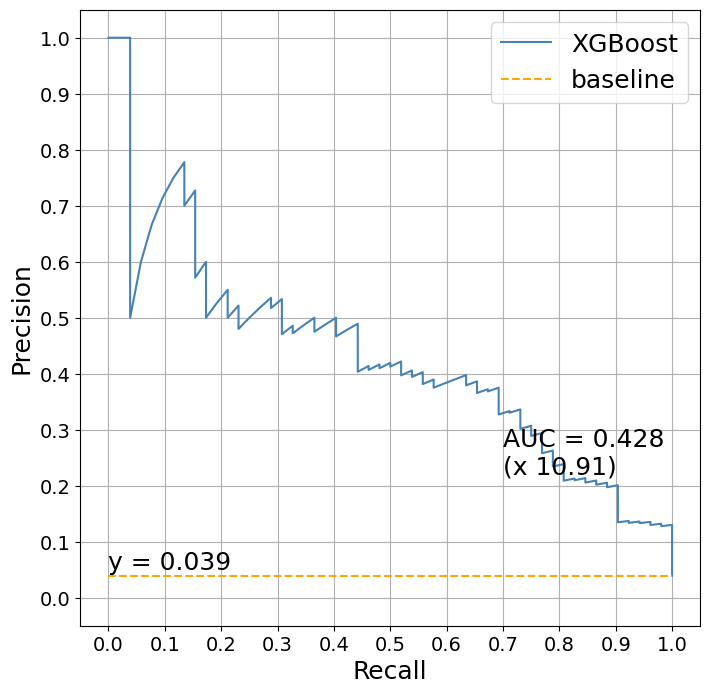

(0.6346, 0.4, 0.4889, 0.76)

In [139]:
plot_pr_curve(df_test, score_col = 'risk_score',target_col = 'target', model_name='XGBoost', plot_fbeta=False, beta = 1)

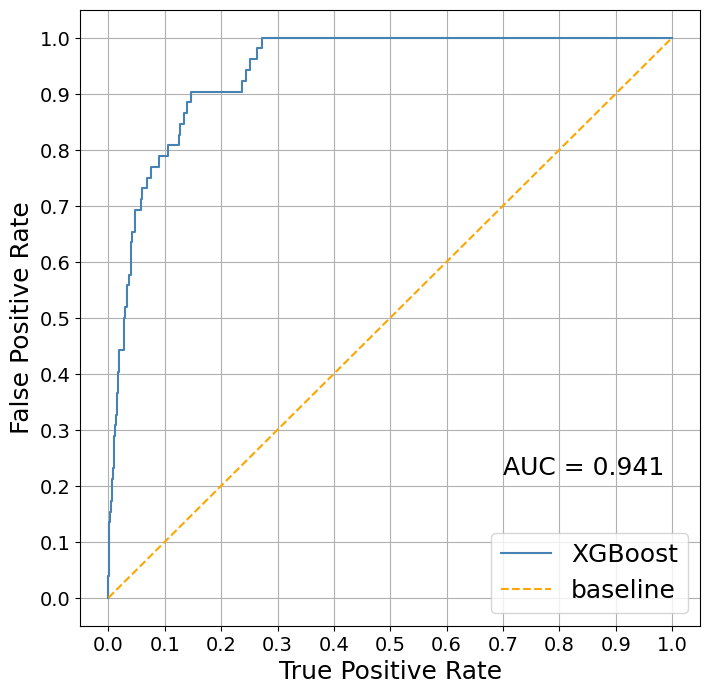

(0.1468, 0.9038, 0.8782, 0.532)

In [140]:
plot_roc_curve(df_test, score_col = 'risk_score',target_col = 'target', model_name='XGBoost')

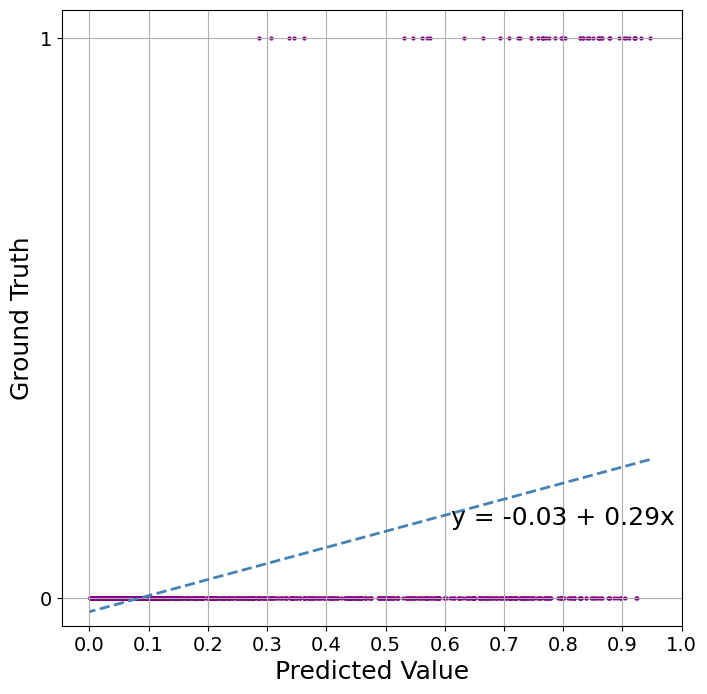

(-0.02501066161769951, 0.2872099656392647)

In [141]:
plot_probability_curve(df_test,score_column = 'risk_score', target_col = 'target', marker_size=4, x_label = 'Predicted Value', marker_shape='o')